# Noise-tolerant Rydberg gate reproduction starter

This notebook belongs to a two-paper reproduction line:

- Zhang et al., *Logical Qubits with Erasure Conversion Using Metastable Neutral Atoms*, Nature Physics 22, 910-916 (2026), DOI `10.1038/s41567-026-03309-0`, BibTeX key `zhangLogicalQubitsErasure2026`.
- Jandura, Thompson, and Pupillo, *Optimizing Rydberg Gates for Logical-Qubit Performance*, PRX Quantum 4, 020336 (2023), DOI `10.1103/PRXQuantum.4.020336`, BibTeX key `janduraOptimizingRydbergGates2023`.

The current executable section starts from the PRX Quantum blockade-limit Hamiltonian and reproduces the first baseline needed before optimizing robust pulses: physical CZ infidelity under amplitude and detuning imperfections for a time-optimal phase seed already present in this repository.

The Nature Physics erasure-conversion line will be added after the physical channel is validated, so that erasure-like and unlocated computational errors are derived from the same simulated gate channel rather than assigned by hand.

## Physical assumptions

- Two neutral-atom qubits use computational states `|0>` and `|1>` plus a Rydberg auxiliary state `|r>`.
- A single global laser couples `|1> <-> |r>` with complex Rabi frequency `Omega(t) = |Omega| exp(i phi(t))`.
- Perfect blockade is assumed in the starter model, so `|rr>` is excluded from the two-excitation branch.
- Amplitude inhomogeneity is represented by atom-dependent scale errors `epsilon_i`.
- Doppler or laser-frequency error is represented by atom-dependent detunings `Delta_i`.
- Optional no-jump Rydberg decay can be included with `-i gamma / 2` on Rydberg levels, but the first scans use `gamma = 0`.

The branch Hamiltonians follow the paper's Sec. II notation:

`H = H10 direct_sum H01 direct_sum H11`, where `H10` and `H01` are two-level branches and `H11` is the blockaded three-state branch `|11>, |r1>, |1r>`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-neutral-yb")

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import least_squares, minimize

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from neutral_yb.models.evered2023_parallel_cz import Evered2023TimeOptimalPulse
from neutral_yb.config.species import idealised_yb171
from neutral_yb.models.global_cz_4d import GlobalCZ4DModel
from neutral_yb.optimization.grape import ClosedSystemGRAPE
from neutral_yb.optimization.global_phase_grape import GlobalPhaseOptimizationConfig
from neutral_yb.analysis.noise_tolerant_rydberg import (
    propagate_blockade_branches as propagate_blockade_branches_first_order,
    propagate_first_order_sensitivity,
)


## Paper metadata container

Purpose: keep paper identity and starter reproduction scope attached to all outputs generated by this notebook.

Inputs: no numerical inputs; this class only stores bibliographic metadata and textual scope.

Outputs: immutable metadata values used in notebook displays and artifact headers if this work later matures into an experiment script.

Assumptions: citation keys are read from the user-maintained `Slides/noise_tolerant_rydberg_reproduction/main.bib`. Codex does not add or rewrite BibTeX entries.

In [2]:
@dataclass(frozen=True)
class PaperMetadata:
    bib_key: str
    title: str
    authors: tuple[str, ...]
    journal: str
    year: int
    doi: str
    role: str

In [3]:
nature_metadata = PaperMetadata(
    bib_key="zhangLogicalQubitsErasure2026",
    title="Logical Qubits with Erasure Conversion Using Metastable Neutral Atoms",
    authors=("Bichen Zhang", "Genyue Liu", "Guillaume Bornet", "Jeff D. Thompson"),
    journal="Nature Physics",
    year=2026,
    doi="10.1038/s41567-026-03309-0",
    role="Erasure-conversion and logical-qubit target line.",
)

prx_metadata = PaperMetadata(
    bib_key="janduraOptimizingRydbergGates2023",
    title="Optimizing Rydberg Gates for Logical-Qubit Performance",
    authors=("Sven Jandura", "Jeff D. Thompson", "Guido Pupillo"),
    journal="PRX Quantum",
    year=2023,
    doi="10.1103/PRXQuantum.4.020336",
    role="Physical robust-pulse and gate-channel target line.",
)

project_papers = (nature_metadata, prx_metadata)
project_papers

(PaperMetadata(bib_key='zhangLogicalQubitsErasure2026', title='Logical Qubits with Erasure Conversion Using Metastable Neutral Atoms', authors=('Bichen Zhang', 'Genyue Liu', 'Guillaume Bornet', 'Jeff D. Thompson'), journal='Nature Physics', year=2026, doi='10.1038/s41567-026-03309-0', role='Erasure-conversion and logical-qubit target line.'),
 PaperMetadata(bib_key='janduraOptimizingRydbergGates2023', title='Optimizing Rydberg Gates for Logical-Qubit Performance', authors=('Sven Jandura', 'Jeff D. Thompson', 'Guido Pupillo'), journal='PRX Quantum', year=2023, doi='10.1103/PRXQuantum.4.020336', role='Physical robust-pulse and gate-channel target line.'))

## Complex Rabi frequency

Purpose: represent the experimentally controlled phase-only pulse as a complex coupling.

Inputs: dimensionless amplitude and phase in radians.

Outputs: complex `Omega = amplitude * exp(i phase)`.

Assumptions: the notebook uses units with `hbar = 1` and frequencies normalized to `Omega_max`, so the default maximum amplitude is `1`.

In [4]:
def complex_rabi(amplitude: float, phase: float) -> complex:
    return complex(float(amplitude) * np.exp(1j * float(phase)))

## Blockaded branch Hamiltonians

Purpose: construct `H10`, `H01`, and `H11` from the paper's blockade-limit model.

Inputs: complex Rabi frequency, atom-dependent amplitude errors, atom-dependent detunings, and optional no-jump decay rate.

Outputs: dense complex NumPy matrices for the three independent branches.

Assumptions: perfect blockade removes `|rr>`. Detunings are constant during one gate. Rydberg decay is included only as a no-jump non-Hermitian diagnostic when `gamma > 0`.

In [5]:
def blockaded_branch_hamiltonians(
    rabi: complex,
    *,
    epsilon_1: float = 0.0,
    epsilon_2: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    gamma: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    h10 = np.zeros((2, 2), dtype=np.complex128)
    h01 = np.zeros((2, 2), dtype=np.complex128)
    h11 = np.zeros((3, 3), dtype=np.complex128)

    omega_1 = (1.0 + float(epsilon_1)) * complex(rabi)
    omega_2 = (1.0 + float(epsilon_2)) * complex(rabi)
    decay = -0.5j * max(float(gamma), 0.0)

    h10[0, 1] = 0.5 * omega_1
    h10[1, 0] = 0.5 * np.conjugate(omega_1)
    h10[1, 1] = float(detuning_1) + decay

    h01[0, 1] = 0.5 * omega_2
    h01[1, 0] = 0.5 * np.conjugate(omega_2)
    h01[1, 1] = float(detuning_2) + decay

    h11[0, 1] = 0.5 * omega_1
    h11[1, 0] = 0.5 * np.conjugate(omega_1)
    h11[0, 2] = 0.5 * omega_2
    h11[2, 0] = 0.5 * np.conjugate(omega_2)
    h11[1, 1] = float(detuning_1) + decay
    h11[2, 2] = float(detuning_2) + decay

    return h10, h01, h11

## Branch propagation

Purpose: propagate the three independent Hamiltonian branches under a piecewise-constant phase pulse.

Inputs: phase samples, total dimensionless gate time, amplitude, imperfections, and optional no-jump decay.

Outputs: final states for the `|10>`, `|01>`, and `|11>` branches.

Assumptions: phase samples are slot centers. Each slot Hamiltonian is constant for `dt = total_time / num_slots`.

In [6]:
def propagate_branch(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude: float = 1.0,
    epsilon_1: float = 0.0,
    epsilon_2: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    gamma: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    phases = np.asarray(phases, dtype=np.float64)
    dt = float(total_time) / int(phases.size)

    state10 = np.array([1.0, 0.0], dtype=np.complex128)
    state01 = np.array([1.0, 0.0], dtype=np.complex128)
    state11 = np.array([1.0, 0.0, 0.0], dtype=np.complex128)

    for phase in phases:
        h10, h01, h11 = blockaded_branch_hamiltonians(
            complex_rabi(amplitude, phase),
            epsilon_1=epsilon_1,
            epsilon_2=epsilon_2,
            detuning_1=detuning_1,
            detuning_2=detuning_2,
            gamma=gamma,
        )
        state10 = expm(-1j * h10 * dt) @ state10
        state01 = expm(-1j * h01 * dt) @ state01
        state11 = expm(-1j * h11 * dt) @ state11

    return state10, state01, state11

## Diagonal CZ process fidelity

Purpose: score the active computational map after leakage is projected away.

Inputs: branch amplitudes `alpha10`, `alpha01`, `beta11` and local phases `theta10`, `theta01`.

Outputs: process fidelity in `[0, 1]`.

Assumptions: the map is diagonal in the computational basis. Population outside the computational amplitudes lowers the overlap through nonunit modulus amplitudes.

In [7]:
def diagonal_cz_process_fidelity_general(
    alpha10: complex,
    alpha01: complex,
    beta11: complex,
    theta10: float,
    theta01: float,
) -> float:
    overlap = (
        1.0
        + np.exp(-1j * float(theta10)) * complex(alpha10)
        + np.exp(-1j * float(theta01)) * complex(alpha01)
        - np.exp(-1j * (float(theta10) + float(theta01))) * complex(beta11)
    )
    return float(abs(overlap) ** 2 / 16.0)

## Local phase optimization

Purpose: maximize the diagonal CZ process fidelity over single-qubit phase corrections.

Inputs: final computational branch amplitudes.

Outputs: optimal local phases and process fidelity.

Assumptions: this removes deterministic local `Z` phases, matching the paper's statement that the CZ is considered up to single-qubit rotations.

In [8]:
def optimize_local_phases(alpha10: complex, alpha01: complex, beta11: complex) -> tuple[float, float, float]:
    def objective(variables: np.ndarray) -> float:
        theta10, theta01 = variables
        return -diagonal_cz_process_fidelity_general(alpha10, alpha01, beta11, theta10, theta01)

    starts = (
        np.array([0.0, 0.0], dtype=np.float64),
        np.array([np.angle(alpha10), np.angle(alpha01)], dtype=np.float64),
        np.array([np.pi, np.pi], dtype=np.float64),
    )
    best = None
    for start in starts:
        result = minimize(objective, start, method="Nelder-Mead", options={"xatol": 1e-11, "fatol": 1e-13})
        if best is None or result.fun < best.fun:
            best = result
    assert best is not None
    theta10, theta01 = np.mod(best.x, 2.0 * np.pi)
    fidelity = -float(best.fun)
    return float(theta10), float(theta01), fidelity

## Pulse evaluation

Purpose: combine propagation, phase optimization, fidelity reporting, and leakage diagnostics.

Inputs: phase samples, total time, amplitude, amplitude errors, detunings, and optional no-jump decay.

Outputs: a dictionary containing amplitudes, optimized phases, process fidelity, infidelity, and mean leakage-like loss from the active computational subspace.

Assumptions: leakage is approximated from branch norm not returning to the original computational basis state. This is a starter diagnostic, not yet the full erasure-channel decomposition used for logical performance.

In [9]:
def evaluate_pulse(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude: float = 1.0,
    epsilon_1: float = 0.0,
    epsilon_2: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    gamma: float = 0.0,
) -> dict[str, float | complex]:
    state10, state01, state11 = propagate_branch(
        phases,
        total_time=total_time,
        amplitude=amplitude,
        epsilon_1=epsilon_1,
        epsilon_2=epsilon_2,
        detuning_1=detuning_1,
        detuning_2=detuning_2,
        gamma=gamma,
    )
    alpha10 = complex(state10[0])
    alpha01 = complex(state01[0])
    beta11 = complex(state11[0])
    theta10, theta01, fidelity = optimize_local_phases(alpha10, alpha01, beta11)
    active_population = (1.0 + abs(alpha10) ** 2 + abs(alpha01) ** 2 + abs(beta11) ** 2) / 4.0
    return {
        "alpha10": alpha10,
        "alpha01": alpha01,
        "beta11": beta11,
        "theta10": theta10,
        "theta01": theta01,
        "process_fidelity": fidelity,
        "process_infidelity": float(1.0 - fidelity),
        "active_population": float(active_population),
        "leakage_like_loss": float(1.0 - active_population),
    }

## Time-optimal seed pulse

Purpose: create a concrete phase-only pulse for the first baseline scans.

Inputs: number of time slots.

Outputs: phase samples and dimensionless duration.

Assumptions: this uses the repository's current time-optimal phase profile from the ideal global-CZ/Evered line as a seed. It is not yet the PRX paper's AR/DR/ADR pulse data.

In [10]:
def seed_phase_profile(num_tslots: int = 160) -> tuple[np.ndarray, float]:
    pulse = Evered2023TimeOptimalPulse()
    phases = pulse.sampled_phases(int(num_tslots))
    return phases.astype(np.float64), float(pulse.dimensionless_duration)

dimensionless duration Omega_max*T = 7.634070
nominal process fidelity = 0.999993035320
nominal leakage-like loss = 6.959e-06


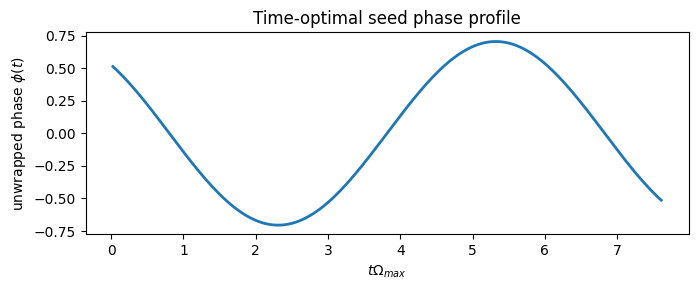

In [11]:
phases, total_time = seed_phase_profile(num_tslots=160)
nominal = evaluate_pulse(phases, total_time=total_time)

print(f"dimensionless duration Omega_max*T = {total_time:.6f}")
print(f"nominal process fidelity = {nominal['process_fidelity']:.12f}")
print(f"nominal leakage-like loss = {nominal['leakage_like_loss']:.3e}")

times = (np.arange(phases.size) + 0.5) * total_time / phases.size
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(times, np.unwrap(phases), lw=2)
ax.set_xlabel(r"$t\Omega_{max}$")
ax.set_ylabel(r"unwrapped phase $\phi(t)$")
ax.set_title("Time-optimal seed phase profile")
fig.tight_layout()

## Amplitude-error scan

Purpose: reproduce the first kind of physical imperfection scan: common laser-amplitude error.

Inputs: phase samples, total time, and an array of common `epsilon` values.

Outputs: a table-like dictionary of `epsilon`, fidelity, infidelity, and leakage-like loss.

Assumptions: this scan sets `epsilon_1 = epsilon_2 = epsilon`. Independent amplitude errors are a later extension.

In [12]:
def scan_amplitude_error(phases: np.ndarray, *, total_time: float, values: np.ndarray) -> dict[str, np.ndarray]:
    fidelities = []
    losses = []
    for epsilon in np.asarray(values, dtype=np.float64):
        result = evaluate_pulse(
            phases,
            total_time=total_time,
            epsilon_1=float(epsilon),
            epsilon_2=float(epsilon),
        )
        fidelities.append(float(result["process_fidelity"]))
        losses.append(float(result["leakage_like_loss"]))
    fidelities_array = np.asarray(fidelities, dtype=np.float64)
    return {
        "epsilon": np.asarray(values, dtype=np.float64),
        "process_fidelity": fidelities_array,
        "process_infidelity": 1.0 - fidelities_array,
        "leakage_like_loss": np.asarray(losses, dtype=np.float64),
    }

## Single-atom detuning scan

Purpose: reproduce the Fig. 2(b)-style baseline imperfection scan: detuning on atom 1 with atom 2 held resonant.

Inputs: phase samples, total time, and an array of detuning values in units of `Omega_max`.

Outputs: a table-like dictionary of detuning, fidelity, infidelity, and leakage-like loss.

Assumptions: this scan sets `Delta_1 = Delta` and `Delta_2 = 0`, matching the PRX Quantum Fig. 2(b) convention. A common-detuning helper is retained for laser-frequency-noise diagnostics, but it is not used for the Fig. 2 comparison.


In [13]:

def scan_common_detuning(phases: np.ndarray, *, total_time: float, values: np.ndarray) -> dict[str, np.ndarray]:
    fidelities = []
    losses = []
    for detuning in np.asarray(values, dtype=np.float64):
        result = evaluate_pulse(
            phases,
            total_time=total_time,
            detuning_1=float(detuning),
            detuning_2=float(detuning),
        )
        fidelities.append(float(result["process_fidelity"]))
        losses.append(float(result["leakage_like_loss"]))
    fidelities_array = np.asarray(fidelities, dtype=np.float64)
    return {
        "detuning": np.asarray(values, dtype=np.float64),
        "process_fidelity": fidelities_array,
        "process_infidelity": 1.0 - fidelities_array,
        "leakage_like_loss": np.asarray(losses, dtype=np.float64),
    }


def scan_single_atom_detuning(
    phases: np.ndarray,
    *,
    total_time: float,
    values: np.ndarray,
    detuned_atom: int = 1,
) -> dict[str, np.ndarray]:
    fidelities = []
    losses = []
    for detuning in np.asarray(values, dtype=np.float64):
        detuning_1 = float(detuning) if int(detuned_atom) == 1 else 0.0
        detuning_2 = float(detuning) if int(detuned_atom) == 2 else 0.0
        result = evaluate_pulse(
            phases,
            total_time=total_time,
            detuning_1=detuning_1,
            detuning_2=detuning_2,
        )
        fidelities.append(float(result["process_fidelity"]))
        losses.append(float(result["leakage_like_loss"]))
    fidelities_array = np.asarray(fidelities, dtype=np.float64)
    return {
        "detuning": np.asarray(values, dtype=np.float64),
        "process_fidelity": fidelities_array,
        "process_infidelity": 1.0 - fidelities_array,
        "leakage_like_loss": np.asarray(losses, dtype=np.float64),
    }


## Scan plotting

Purpose: produce the first figures that can later move into the Beamer report.

Inputs: amplitude and detuning scan dictionaries.

Outputs: a two-panel matplotlib figure of process infidelity versus imperfection strength.

Assumptions: log scale is useful because robust-pulse targets in the paper suppress error by orders of magnitude.

In [14]:

def plot_infidelity_scans(amplitude_scan: dict[str, np.ndarray], detuning_scan: dict[str, np.ndarray]) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

    axes[0].semilogy(amplitude_scan["epsilon"], amplitude_scan["process_infidelity"], marker="o", ms=3)
    axes[0].set_xlabel(r"common amplitude error $\epsilon$")
    axes[0].set_ylabel(r"process infidelity $1-F_{pro}$")
    axes[0].set_title("Time Optimal: amplitude error")
    axes[0].grid(True, which="both", alpha=0.25)

    axes[1].semilogy(detuning_scan["detuning"], detuning_scan["process_infidelity"], marker="o", ms=3)
    axes[1].set_xlabel(r"single-atom detuning $\Delta_1/\Omega_{max}$")
    axes[1].set_ylabel(r"process infidelity $1-F_{pro}$")
    axes[1].set_title(r"Time Optimal: $\Delta_1$, $\Delta_2=0$")
    axes[1].grid(True, which="both", alpha=0.25)

    fig.tight_layout()


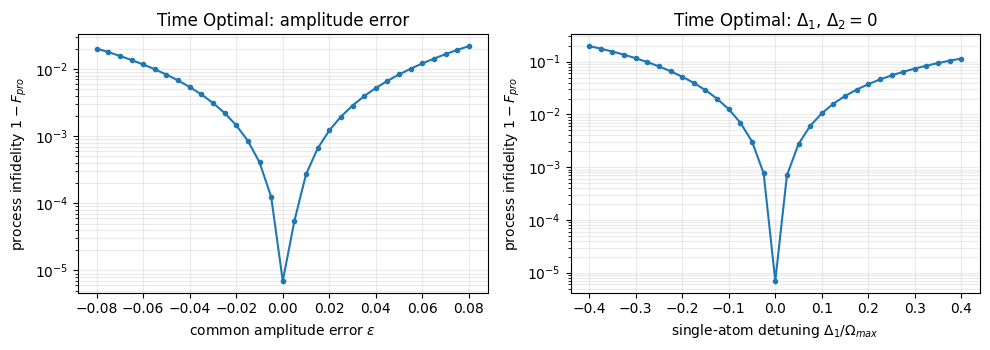

In [15]:

epsilon_values = np.linspace(-0.08, 0.08, 33)
detuning_values = np.linspace(-0.40, 0.40, 33)

amplitude_scan = scan_amplitude_error(phases, total_time=total_time, values=epsilon_values)
detuning_scan = scan_single_atom_detuning(phases, total_time=total_time, values=detuning_values, detuned_atom=1)

plot_infidelity_scans(amplitude_scan, detuning_scan)


## Next implementation checkpoint

The next cell group should add first-order sensitivity states. For amplitude robustness, propagate `psi_q^(0)` and `psi_q^(1)` together and minimize

`J = 1 - F + sum_q <psi_q^(1) | psi_q^(1)>`.

For Doppler robustness, add the two-half construction where the sign of the Doppler detuning is reversed between pulse halves. Only after those physical channels are verified should the notebook move to the erasure-biased logical-performance surrogate described in the paper.

## OT/AR/DR first-pass reproduction setup

The PRX Quantum paper distinguishes time-optimal (TO), amplitude-robust (AR), and Doppler-robust (DR) pulse families. This section starts a reproducible numerical attempt with a deliberately compact control parametrization.

Physical meaning:

- OT: the current repository time-optimal phase seed, used as the baseline gate.
- AR: a longer phase-only pulse optimized to reduce sensitivity to common amplitude error.
- DR: a two-half phase-only pulse evaluated with detuning sign reversal between halves, optimized to reduce Doppler-like detuning sensitivity.

This is not yet the final paper-grade GRAPE reproduction. It is the first executable scaffold for checking model conventions, robustness objectives, and plots before moving mature logic into `src/neutral_yb/`.

## Duration-scaled seed phase profile

Purpose: produce a smooth phase-only seed at a requested dimensionless duration.

Inputs: total dimensionless time and number of slot-center samples.

Outputs: phase samples and the total duration.

Assumptions: this reuses the existing analytic time-optimal phase family as an initial shape. For AR and DR this is only an optimizer seed, not a claim that the paper pulse has this analytic form.

In [16]:
def seed_phase_profile_for_duration(total_time: float, num_tslots: int = 64) -> tuple[np.ndarray, float]:
    pulse = Evered2023TimeOptimalPulse(omega_t_over_2pi=float(total_time) / (2.0 * np.pi))
    dt = float(total_time) / int(num_tslots)
    centers = (np.arange(int(num_tslots), dtype=np.float64) + 0.5) * dt
    phases = np.mod(pulse.phase(centers), 2.0 * np.pi)
    return phases.astype(np.float64), float(total_time)


## Fourier phase correction

Purpose: define a low-dimensional smooth phase correction for exploratory robust-pulse optimization.

Inputs: slot-center times, total duration, and sine/cosine coefficients.

Outputs: a correction array with the same length as `times`.

Assumptions: coefficients are ordered as `[sin_1, cos_1, sin_2, cos_2, ...]`. This compact basis is used only for early exploration; a full GRAPE reproduction should later optimize slot phases or a documented basis matching the paper.

In [17]:
def fourier_phase_correction(times: np.ndarray, total_time: float, coefficients: np.ndarray) -> np.ndarray:
    times = np.asarray(times, dtype=np.float64)
    coefficients = np.asarray(coefficients, dtype=np.float64)
    if coefficients.size % 2 != 0:
        raise ValueError("coefficients must contain sine/cosine pairs")
    correction = np.zeros_like(times, dtype=np.float64)
    scaled = 2.0 * np.pi * times / float(total_time)
    for mode in range(coefficients.size // 2):
        sine = coefficients[2 * mode]
        cosine = coefficients[2 * mode + 1]
        harmonic = float(mode + 1)
        correction += sine * np.sin(harmonic * scaled) + cosine * np.cos(harmonic * scaled)
    return correction


## Compact phase family

Purpose: combine a seed phase profile with a smooth Fourier correction.

Inputs: base phase samples, total duration, and correction coefficients.

Outputs: corrected phase samples.

Assumptions: phase wrapping is not required for the Hamiltonian because only `exp(i phase)` enters the Rabi coupling; the returned values are kept continuous for plotting and optimization.

In [18]:
def compact_phase_family(base_phases: np.ndarray, total_time: float, coefficients: np.ndarray) -> np.ndarray:
    base_phases = np.asarray(base_phases, dtype=np.float64)
    times = (np.arange(base_phases.size, dtype=np.float64) + 0.5) * (float(total_time) / base_phases.size)
    return base_phases + fourier_phase_correction(times, total_time, coefficients)


## Trace-based branch propagation

Purpose: propagate the same blockaded branch model while allowing slot-wise amplitude and detuning traces.

Inputs: phase samples, total time, optional slot traces for amplitude errors and detunings, and optional no-jump decay.

Outputs: final states for the `|10>`, `|01>`, and `|11>` branches.

Assumptions: all traces are piecewise constant at slot centers. This is needed for DR because the Doppler-like detuning changes sign between pulse halves.

In [19]:
def propagate_branch_with_traces(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude: float = 1.0,
    epsilon_1_trace: np.ndarray | None = None,
    epsilon_2_trace: np.ndarray | None = None,
    detuning_1_trace: np.ndarray | None = None,
    detuning_2_trace: np.ndarray | None = None,
    gamma: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    phases = np.asarray(phases, dtype=np.float64)
    slots = int(phases.size)
    dt = float(total_time) / slots

    eps1 = np.zeros(slots, dtype=np.float64) if epsilon_1_trace is None else np.asarray(epsilon_1_trace, dtype=np.float64)
    eps2 = np.zeros(slots, dtype=np.float64) if epsilon_2_trace is None else np.asarray(epsilon_2_trace, dtype=np.float64)
    det1 = np.zeros(slots, dtype=np.float64) if detuning_1_trace is None else np.asarray(detuning_1_trace, dtype=np.float64)
    det2 = np.zeros(slots, dtype=np.float64) if detuning_2_trace is None else np.asarray(detuning_2_trace, dtype=np.float64)
    for name, trace in (("epsilon_1_trace", eps1), ("epsilon_2_trace", eps2), ("detuning_1_trace", det1), ("detuning_2_trace", det2)):
        if trace.shape != (slots,):
            raise ValueError(f"{name} must have shape {(slots,)}")

    state10 = np.array([1.0, 0.0], dtype=np.complex128)
    state01 = np.array([1.0, 0.0], dtype=np.complex128)
    state11 = np.array([1.0, 0.0, 0.0], dtype=np.complex128)

    for index, phase in enumerate(phases):
        h10, h01, h11 = blockaded_branch_hamiltonians(
            complex_rabi(amplitude, phase),
            epsilon_1=float(eps1[index]),
            epsilon_2=float(eps2[index]),
            detuning_1=float(det1[index]),
            detuning_2=float(det2[index]),
            gamma=gamma,
        )
        state10 = expm(-1j * h10 * dt) @ state10
        state01 = expm(-1j * h01 * dt) @ state01
        state11 = expm(-1j * h11 * dt) @ state11

    return state10, state01, state11


## Trace-pulse evaluation

Purpose: score a pulse with slot-wise imperfections using the same diagonal CZ process-fidelity convention.

Inputs: phase samples, total time, optional amplitude/detuning traces, and optional no-jump decay.

Outputs: amplitudes, optimized local phases, process fidelity, process infidelity, and leakage-like loss.

Assumptions: the map remains diagonal in the computational basis after projecting the three propagated branches back onto their initial computational states.

In [20]:
def evaluate_trace_pulse(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude: float = 1.0,
    epsilon_1_trace: np.ndarray | None = None,
    epsilon_2_trace: np.ndarray | None = None,
    detuning_1_trace: np.ndarray | None = None,
    detuning_2_trace: np.ndarray | None = None,
    gamma: float = 0.0,
) -> dict[str, float | complex]:
    state10, state01, state11 = propagate_branch_with_traces(
        phases,
        total_time=total_time,
        amplitude=amplitude,
        epsilon_1_trace=epsilon_1_trace,
        epsilon_2_trace=epsilon_2_trace,
        detuning_1_trace=detuning_1_trace,
        detuning_2_trace=detuning_2_trace,
        gamma=gamma,
    )
    alpha10 = complex(state10[0])
    alpha01 = complex(state01[0])
    beta11 = complex(state11[0])
    theta10, theta01, fidelity = optimize_local_phases(alpha10, alpha01, beta11)
    active_population = (1.0 + abs(alpha10) ** 2 + abs(alpha01) ** 2 + abs(beta11) ** 2) / 4.0
    return {
        "alpha10": alpha10,
        "alpha01": alpha01,
        "beta11": beta11,
        "theta10": theta10,
        "theta01": theta01,
        "process_fidelity": fidelity,
        "process_infidelity": float(1.0 - fidelity),
        "active_population": float(active_population),
        "leakage_like_loss": float(1.0 - active_population),
    }


## Doppler sign-reversal traces

Purpose: create the detuning traces used in the DR protocol, where the Doppler shift changes sign between two pulse halves.

Inputs: number of slots and Doppler-like detuning value.

Outputs: two identical atom detuning traces for the common-detuning case.

Assumptions: this first pass models a common Doppler shift and an exact sign reversal at the pulse midpoint. The full paper also discusses physical switch/wait implementations of this reversal.

In [21]:

def single_atom_detuning_traces(
    num_tslots: int,
    detuning: float,
    *,
    detuned_atom: int = 1,
    use_doppler_reversal: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    slots = int(num_tslots)
    trace = np.full(slots, float(detuning), dtype=np.float64)
    if use_doppler_reversal:
        trace[slots // 2 :] *= -1.0
    zeros = np.zeros(slots, dtype=np.float64)
    if int(detuned_atom) == 1:
        return trace, zeros
    if int(detuned_atom) == 2:
        return zeros, trace
    raise ValueError("detuned_atom must be 1 or 2")


def doppler_reversal_detuning_traces(num_tslots: int, detuning: float) -> tuple[np.ndarray, np.ndarray]:
    return single_atom_detuning_traces(
        num_tslots,
        detuning,
        detuned_atom=1,
        use_doppler_reversal=True,
    )


## Amplitude-robust objective

Purpose: define the first-pass AR optimization objective.

Inputs: Fourier coefficients, base phases, total duration, a probe amplitude error, and a robustness weight.

Outputs: scalar cost to minimize.

Assumptions: true AR GRAPE should propagate first-order sensitivity states. This notebook begins with a finite-difference robustness proxy: it penalizes infidelity at `+epsilon` and `-epsilon` while keeping the nominal gate high fidelity.

In [22]:
def amplitude_robust_objective(
    coefficients: np.ndarray,
    *,
    base_phases: np.ndarray,
    total_time: float,
    probe_epsilon: float = 0.04,
    robustness_weight: float = 1.0,
    regularization_weight: float = 1e-4,
) -> float:
    phases = compact_phase_family(base_phases, total_time, coefficients)
    nominal = evaluate_pulse(phases, total_time=total_time)
    plus = evaluate_pulse(phases, total_time=total_time, epsilon_1=probe_epsilon, epsilon_2=probe_epsilon)
    minus = evaluate_pulse(phases, total_time=total_time, epsilon_1=-probe_epsilon, epsilon_2=-probe_epsilon)
    correction_penalty = regularization_weight * float(np.mean(np.asarray(coefficients, dtype=np.float64) ** 2))
    return float(
        nominal["process_infidelity"]
        + robustness_weight * (plus["process_infidelity"] + minus["process_infidelity"])
        + correction_penalty
    )


## Doppler-robust objective

Purpose: define the first-pass DR optimization objective with midpoint detuning sign reversal.

Inputs: Fourier coefficients, base phases, total duration, a probe detuning, and a robustness weight.

Outputs: scalar cost to minimize.

Assumptions: the objective uses an exact trace sign reversal and penalizes `+Delta` and `-Delta` probes. This is a compact-basis proxy for the paper's DR construction, not yet a full GRAPE sensitivity objective.

In [23]:

def doppler_robust_objective(
    coefficients: np.ndarray,
    *,
    base_phases: np.ndarray,
    total_time: float,
    probe_detuning: float = 0.20,
    robustness_weight: float = 1.0,
    regularization_weight: float = 1e-4,
) -> float:
    phases = compact_phase_family(base_phases, total_time, coefficients)
    nominal = evaluate_trace_pulse(phases, total_time=total_time)
    plus_det1, plus_det2 = single_atom_detuning_traces(
        phases.size,
        probe_detuning,
        detuned_atom=1,
        use_doppler_reversal=True,
    )
    minus_det1, minus_det2 = single_atom_detuning_traces(
        phases.size,
        -probe_detuning,
        detuned_atom=1,
        use_doppler_reversal=True,
    )
    plus = evaluate_trace_pulse(
        phases,
        total_time=total_time,
        detuning_1_trace=plus_det1,
        detuning_2_trace=plus_det2,
    )
    minus = evaluate_trace_pulse(
        phases,
        total_time=total_time,
        detuning_1_trace=minus_det1,
        detuning_2_trace=minus_det2,
    )
    correction_penalty = regularization_weight * float(np.mean(np.asarray(coefficients, dtype=np.float64) ** 2))
    return float(
        nominal["process_infidelity"]
        + robustness_weight * (plus["process_infidelity"] + minus["process_infidelity"])
        + correction_penalty
    )


## Compact optimizer

Purpose: optimize a small set of Fourier phase coefficients without introducing reusable project APIs yet.

Inputs: an objective callable, number of Fourier modes, and maximum iterations.

Outputs: optimized coefficient vector and the raw SciPy optimizer result.

Assumptions: Nelder-Mead is acceptable for the early notebook because there are only a few coefficients and gradients are not yet implemented. Mature GRAPE should replace this with analytic gradients.

In [24]:
def optimize_compact_phase_family(
    objective,
    *,
    num_modes: int = 2,
    max_iter: int = 35,
    initial_scale: float = 0.02,
) -> tuple[np.ndarray, object]:
    variables0 = np.full(2 * int(num_modes), float(initial_scale), dtype=np.float64)
    result = minimize(
        objective,
        variables0,
        method="Nelder-Mead",
        options={"maxiter": int(max_iter), "xatol": 1e-4, "fatol": 1e-8, "disp": False},
    )
    return np.asarray(result.x, dtype=np.float64), result


## Gate-candidate summary

Purpose: collect comparable scalar diagnostics for OT, AR, and DR candidate pulses.

Inputs: label, phases, duration, and optional DR detuning probe.

Outputs: a plain dictionary suitable for printing or later conversion to a table.

Assumptions: amplitude robustness is measured under common amplitude error; DR robustness is measured using the midpoint detuning sign reversal trace.

In [25]:

def gate_candidate_summary(
    label: str,
    phases: np.ndarray,
    *,
    total_time: float,
    probe_epsilon: float = 0.04,
    probe_detuning: float = 0.20,
    use_doppler_reversal: bool = False,
) -> dict[str, float | str]:
    nominal = evaluate_trace_pulse(phases, total_time=total_time)
    amp_plus = evaluate_trace_pulse(
        phases,
        total_time=total_time,
        epsilon_1_trace=np.full(phases.size, probe_epsilon),
        epsilon_2_trace=np.full(phases.size, probe_epsilon),
    )
    amp_minus = evaluate_trace_pulse(
        phases,
        total_time=total_time,
        epsilon_1_trace=np.full(phases.size, -probe_epsilon),
        epsilon_2_trace=np.full(phases.size, -probe_epsilon),
    )
    det1, det2 = single_atom_detuning_traces(
        phases.size,
        probe_detuning,
        detuned_atom=1,
        use_doppler_reversal=use_doppler_reversal,
    )
    detuned = evaluate_trace_pulse(phases, total_time=total_time, detuning_1_trace=det1, detuning_2_trace=det2)
    return {
        "label": label,
        "num_tslots": int(phases.size),
        "duration_omega_t": float(total_time),
        "nominal_fidelity": float(nominal["process_fidelity"]),
        "nominal_infidelity": float(nominal["process_infidelity"]),
        "amp_plus_infidelity": float(amp_plus["process_infidelity"]),
        "amp_minus_infidelity": float(amp_minus["process_infidelity"]),
        "detuning_probe_infidelity": float(detuned["process_infidelity"]),
        "leakage_like_loss": float(nominal["leakage_like_loss"]),
    }


## OT/AR/DR error comparison plot

Purpose: visualize the first-pass robust-pulse behavior over common amplitude and detuning probes.

Inputs: a dictionary of candidate pulses with phases, durations, and whether detuning reversal is part of the protocol.

Outputs: two-panel plot of process infidelity versus amplitude error and detuning error.

Assumptions: all plotted fidelities use the same local-phase-optimized process metric. DR detuning scans use sign reversal; OT and AR detuning scans are plotted without reversal unless explicitly marked otherwise in the candidate metadata.

In [26]:

def plot_ot_ar_dr_error_comparison(candidates: dict[str, dict[str, object]]) -> None:
    epsilon_grid = np.linspace(-0.08, 0.08, 17)
    detuning_grid = np.linspace(-0.30, 0.30, 17)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

    for label, candidate in candidates.items():
        phases = np.asarray(candidate["phases"], dtype=np.float64)
        total_time = float(candidate["total_time"])
        amp_errors = []
        for epsilon in epsilon_grid:
            result = evaluate_trace_pulse(
                phases,
                total_time=total_time,
                epsilon_1_trace=np.full(phases.size, epsilon),
                epsilon_2_trace=np.full(phases.size, epsilon),
            )
            amp_errors.append(float(result["process_infidelity"]))
        axes[0].semilogy(epsilon_grid, amp_errors, marker="o", ms=3, label=label)

        detuning_errors = []
        for detuning in detuning_grid:
            det1, det2 = single_atom_detuning_traces(
                phases.size,
                detuning,
                detuned_atom=1,
                use_doppler_reversal=bool(candidate.get("use_doppler_reversal", False)),
            )
            result = evaluate_trace_pulse(phases, total_time=total_time, detuning_1_trace=det1, detuning_2_trace=det2)
            detuning_errors.append(float(result["process_infidelity"]))
        axes[1].semilogy(detuning_grid, detuning_errors, marker="o", ms=3, label=label)

    axes[0].set_xlabel(r"common amplitude error $\epsilon$")
    axes[0].set_ylabel(r"process infidelity $1-F_{pro}$")
    axes[0].set_title("Fig. 2(a)-style amplitude sensitivity")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend()

    axes[1].set_xlabel(r"single-atom detuning $\Delta_1/\Omega_{max}$")
    axes[1].set_ylabel(r"process infidelity $1-F_{pro}$")
    axes[1].set_title(r"Fig. 2(b)-style $\Delta_1$, $\Delta_2=0$")
    axes[1].grid(True, which="both", alpha=0.25)
    axes[1].legend()
    fig.tight_layout()


## Nominal slot-wise GRAPE seed

Purpose: generate a high-fidelity phase seed at a longer duration before applying AR/DR robustness objectives.

Inputs: total duration, number of time slots, and optional initial phases.

Outputs: optimized phase samples and the ideal-model fidelity reached by the existing repository GRAPE implementation.

Assumptions: this uses the repository's validated `GlobalCZ4DModel` as a Time Optimal seed generator. The seed is then re-scored by the branch Hamiltonian in this notebook. This is a practical early-stage bridge, not the final robust-pulse optimizer.

In [27]:
def nominal_grape_phase_seed(
    *,
    total_time: float,
    num_tslots: int,
    initial_phases: np.ndarray | None = None,
    max_iter: int = 100,
    phase_seed: int = 17,
) -> tuple[np.ndarray, float]:
    model = GlobalCZ4DModel(species=idealised_yb171())
    optimizer = ClosedSystemGRAPE.global_phase(
        model=model,
        config=GlobalPhaseOptimizationConfig(
            num_tslots=int(num_tslots),
            evo_time=float(total_time),
            max_iter=int(max_iter),
            phase_seed=int(phase_seed),
            init_phase_spread=0.8,
            fidelity_target=0.9999,
            smoothness_weight=1e-4,
            curvature_weight=1e-5,
            num_restarts=1,
        ),
    )
    result = optimizer.optimize(initial_phases=initial_phases)
    return np.asarray(result.phases, dtype=np.float64).ravel(), float(result.fidelity)


## Execute first-pass OT/AR/DR attempt

This cell performs the first executable attempt for the three pulse families.

- OT is the repository seed at the known time-optimal duration.
- AR is optimized at the paper's reported order-of-magnitude robust duration `Omega*T ~= 14.32` using amplitude-error probes.
- DR is optimized at the same exploratory duration using midpoint detuning sign reversal.

The result should be interpreted as a scaffold and diagnostic, not as the final reproduction of the published pulse shapes.

Time Optimal GRAPE seed fidelity: 0.9866070552
First-pass Time Optimal/AR/DR summaries
Time Optimal: T=7.634, F0=0.9999930353, 1-F(+eps)=5.221e-03, 1-F(det probe)=3.743e-02, L=6.959e-06
AR first pass: T=14.320, F0=0.9884944379, 1-F(+eps)=4.979e-02, 1-F(det probe)=2.263e-02, L=3.274e-03
DR first pass: T=14.320, F0=0.9899073209, 1-F(+eps)=4.785e-02, 1-F(det probe)=2.421e-02, L=3.004e-03
AR optimizer final cost: 8.778947e-02; success=False; nit=45
DR optimizer final cost: 6.331262e-02; success=False; nit=45


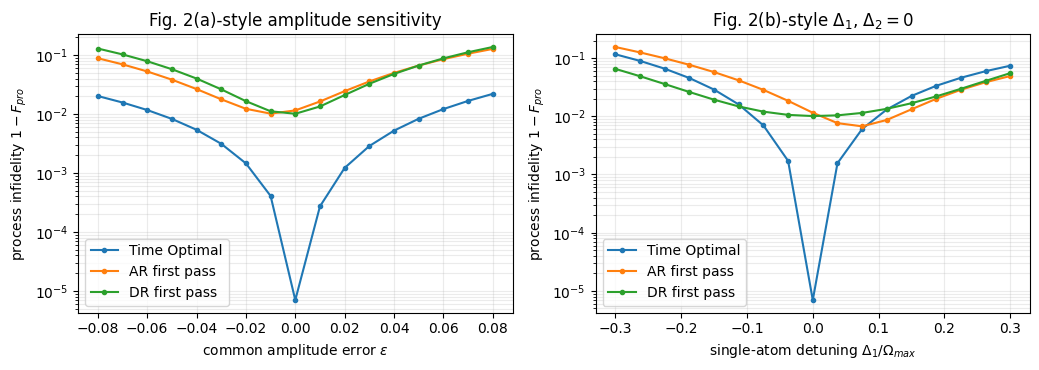

In [28]:
ot_phases, ot_total_time = seed_phase_profile(num_tslots=160)
robust_num_tslots = 40
robust_total_time = 14.32
stretched_base_phases, _ = seed_phase_profile_for_duration(robust_total_time, robust_num_tslots)
nominal_base_phases, nominal_base_fidelity = nominal_grape_phase_seed(
    total_time=robust_total_time,
    num_tslots=robust_num_tslots,
    initial_phases=stretched_base_phases,
    max_iter=120,
)
ar_base_phases = nominal_base_phases.copy()
dr_base_phases = nominal_base_phases.copy()
ar_total_time = robust_total_time
dr_total_time = robust_total_time

ar_coefficients, ar_optimization = optimize_compact_phase_family(
    lambda coeffs: amplitude_robust_objective(
        coeffs,
        base_phases=ar_base_phases,
        total_time=ar_total_time,
        probe_epsilon=0.04,
        robustness_weight=1.0,
    ),
    num_modes=2,
    max_iter=45,
)

dr_coefficients, dr_optimization = optimize_compact_phase_family(
    lambda coeffs: doppler_robust_objective(
        coeffs,
        base_phases=dr_base_phases,
        total_time=dr_total_time,
        probe_detuning=0.20,
        robustness_weight=1.0,
    ),
    num_modes=2,
    max_iter=45,
)

ar_phases = compact_phase_family(ar_base_phases, ar_total_time, ar_coefficients)
dr_phases = compact_phase_family(dr_base_phases, dr_total_time, dr_coefficients)

candidate_pulses = {
    "Time Optimal": {"phases": ot_phases, "total_time": ot_total_time, "use_doppler_reversal": False},
    "AR first pass": {"phases": ar_phases, "total_time": ar_total_time, "use_doppler_reversal": False},
    "DR first pass": {"phases": dr_phases, "total_time": dr_total_time, "use_doppler_reversal": True},
}

summaries = [
    gate_candidate_summary("Time Optimal", ot_phases, total_time=ot_total_time, use_doppler_reversal=False),
    gate_candidate_summary("AR first pass", ar_phases, total_time=ar_total_time, use_doppler_reversal=False),
    gate_candidate_summary("DR first pass", dr_phases, total_time=dr_total_time, use_doppler_reversal=True),
]

print(f"Time Optimal GRAPE seed fidelity: {nominal_base_fidelity:.10f}")
print("First-pass Time Optimal/AR/DR summaries")
for row in summaries:
    print(
        f"{row['label']}: T={row['duration_omega_t']:.3f}, "
        f"F0={row['nominal_fidelity']:.10f}, "
        f"1-F(+eps)={row['amp_plus_infidelity']:.3e}, "
        f"1-F(det probe)={row['detuning_probe_infidelity']:.3e}, "
        f"L={row['leakage_like_loss']:.3e}"
    )
print(f"AR optimizer final cost: {float(ar_optimization.fun):.6e}; success={bool(ar_optimization.success)}; nit={int(ar_optimization.nit)}")
print(f"DR optimizer final cost: {float(dr_optimization.fun):.6e}; success={bool(dr_optimization.success)}; nit={int(dr_optimization.nit)}")

plot_ot_ar_dr_error_comparison(candidate_pulses)


## Interpretation of the first-pass OT/AR/DR run

The saved outputs above are intended to answer three early-stage questions:

1. Does the branch Hamiltonian reproduce a high-fidelity TO seed at zero imperfection?
2. Can a longer smooth phase-only pulse reduce common-amplitude sensitivity under a finite-difference robustness proxy?
3. Does explicitly reversing the detuning sign between halves reduce Doppler-like detuning sensitivity for the DR candidate?

If the answer to any item is negative, the next step is not to claim a paper discrepancy. The next step is to inspect the fidelity convention, phase/gauge convention, duration choice, and robustness objective before moving to full GRAPE.

## Bounded finite-probe robust objective

Purpose: optimize a compact phase correction against explicit finite noise probes rather than only plotting sensitivity after the fact.

Inputs: Fourier coefficients, base phases, total time, a noise kind, probe magnitude, and DR sign-reversal flag.

Outputs: scalar objective combining nominal and probed process infidelities.

Assumptions: this is a controlled notebook reproduction step toward the PRX Quantum AR/DR calculations. It uses the paper-inspired noise families and sign reversal, but still uses a compact Fourier search instead of full first-order GRAPE gradients.

In [29]:

def finite_probe_robust_objective(
    coefficients: np.ndarray,
    *,
    base_phases: np.ndarray,
    total_time: float,
    noise_kind: str,
    probe_value: float,
    use_doppler_reversal: bool = False,
    regularization_weight: float = 1e-4,
    worst_case_weight: float = 5.0,
) -> float:
    phases = compact_phase_family(base_phases, total_time, coefficients)
    probe_results: list[float] = []
    if noise_kind == "amplitude":
        for epsilon in (0.0, -probe_value, -0.5 * probe_value, 0.5 * probe_value, probe_value):
            result = evaluate_trace_pulse(
                phases,
                total_time=total_time,
                epsilon_1_trace=np.full(phases.size, epsilon, dtype=np.float64),
                epsilon_2_trace=np.full(phases.size, epsilon, dtype=np.float64),
            )
            probe_results.append(float(result["process_infidelity"]))
    elif noise_kind == "detuning":
        for detuning in (0.0, -probe_value, -0.5 * probe_value, 0.5 * probe_value, probe_value):
            det1, det2 = single_atom_detuning_traces(
                phases.size,
                detuning,
                detuned_atom=1,
                use_doppler_reversal=use_doppler_reversal,
            )
            result = evaluate_trace_pulse(
                phases,
                total_time=total_time,
                detuning_1_trace=det1,
                detuning_2_trace=det2,
            )
            probe_results.append(float(result["process_infidelity"]))
    else:
        raise ValueError("noise_kind must be 'amplitude' or 'detuning'")

    infidelities = np.asarray(probe_results, dtype=np.float64)
    correction_penalty = regularization_weight * float(np.sum(np.asarray(coefficients, dtype=np.float64) ** 2))
    return float(np.sum(infidelities**2) + worst_case_weight * float(np.max(infidelities) ** 2) + correction_penalty)


## Bounded compact optimizer

Purpose: search a small Fourier correction while preventing the robust objective from destroying the nominal CZ gate.

Inputs: objective callable, number of Fourier modes, iteration budget, and coefficient bounds.

Outputs: optimized coefficient vector and raw SciPy result.

Assumptions: bounded Powell is deterministic for this setup and avoids the large unphysical corrections observed in the first unbounded robust search.

In [30]:
def optimize_bounded_compact_phase_family(
    objective,
    *,
    num_modes: int = 3,
    max_iter: int = 45,
    coefficient_bound: float = 0.5,
) -> tuple[np.ndarray, object]:
    variables0 = np.zeros(2 * int(num_modes), dtype=np.float64)
    bounds = [(-float(coefficient_bound), float(coefficient_bound))] * variables0.size
    result = minimize(
        objective,
        variables0,
        method="Powell",
        bounds=bounds,
        options={"maxiter": int(max_iter), "xtol": 2e-4, "ftol": 1e-7, "disp": False},
    )
    return np.asarray(result.x, dtype=np.float64), result

## Finite-probe fidelity table

Purpose: report the nominal and probed fidelities used to judge whether the robust optimization actually helped.

Inputs: label, phases, total duration, noise kind, probe value, and optional DR sign reversal.

Outputs: dictionary with nominal, half-probe, full-probe, and worst-probe fidelities.

Assumptions: amplitude probes are common-mode amplitude errors on both atoms; detuning probes follow Fig. 2(b), with `Delta_1` varied and `Delta_2=0`. DR probes flip the sign of `Delta_1` at the midpoint.


In [31]:

def finite_probe_fidelity_table(
    label: str,
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    probe_value: float,
    use_doppler_reversal: bool = False,
) -> dict[str, float | str]:
    phases = np.asarray(phases, dtype=np.float64)
    entries: dict[str, float | str] = {"label": label}
    fidelities: list[float] = []
    for name, value in (
        ("minus_probe", -float(probe_value)),
        ("minus_half_probe", -0.5 * float(probe_value)),
        ("nominal", 0.0),
        ("plus_half_probe", 0.5 * float(probe_value)),
        ("plus_probe", float(probe_value)),
    ):
        if noise_kind == "amplitude":
            result = evaluate_trace_pulse(
                phases,
                total_time=total_time,
                epsilon_1_trace=np.full(phases.size, value, dtype=np.float64),
                epsilon_2_trace=np.full(phases.size, value, dtype=np.float64),
            )
        elif noise_kind == "detuning":
            det1, det2 = single_atom_detuning_traces(
                phases.size,
                value,
                detuned_atom=1,
                use_doppler_reversal=use_doppler_reversal,
            )
            result = evaluate_trace_pulse(
                phases,
                total_time=total_time,
                detuning_1_trace=det1,
                detuning_2_trace=det2,
            )
        else:
            raise ValueError("noise_kind must be 'amplitude' or 'detuning'")
        fidelity = float(result["process_fidelity"])
        entries[f"fidelity_{name}"] = fidelity
        entries[f"infidelity_{name}"] = float(1.0 - fidelity)
        fidelities.append(fidelity)
    entries["minimum_probe_fidelity"] = float(np.min(fidelities))
    entries["maximum_probe_infidelity"] = float(1.0 - np.min(fidelities))
    return entries


## Execute bounded finite-probe AR/DR optimization

This cell performs the robust optimization requested after the diagnostic first pass.

- AR uses common amplitude probes at `epsilon = ±0.05` and half probes.
- DR uses Fig. 2(b)-style single-atom detuning probes with midpoint sign reversal at `Delta_1/Omega = ±0.20` and half probes.

The output is the current reproducible robust result in this simplified blockade model. The `Delta_1=0.20` DR improvement is modest, so the table also makes the `Delta_1=0.10` half-probe fidelity explicit.


Finite-probe Time Optimal fidelity: 0.999999761162
Bounded finite-probe robust optimization
Time Optimal, amplitude probes: F(-probe)=0.998697598240, F(-half)=0.999654462235, F0=0.999999811998, F(+half)=0.999603564107, F(+probe)=0.998262227353, minF=0.998262227353
AR finite-probe robust, amplitude probes: F(-probe)=0.998552745966, F(-half)=0.999518810522, F0=0.999927393819, F(+half)=0.999669908397, F(+probe)=0.998552746320, minF=0.998552745966
Time Optimal, DR detuning probes: F(-probe)=0.979062704043, F(-half)=0.995241108740, F0=0.999999811998, F(+half)=0.995237579871, F(+probe)=0.979043468996, minF=0.979043468996
DR finite-probe robust, DR detuning probes: F(-probe)=0.980303143863, F(-half)=0.994809387905, F0=0.998971262643, F(+half)=0.994808664688, F(+probe)=0.980304062845, minF=0.980303143863
AR finite-probe optimizer: success=True; nit=15; nfev=1485; objective=1.501344e-05
DR finite-probe optimizer: success=True; nit=5; nfev=318; objective=2.771196e-03


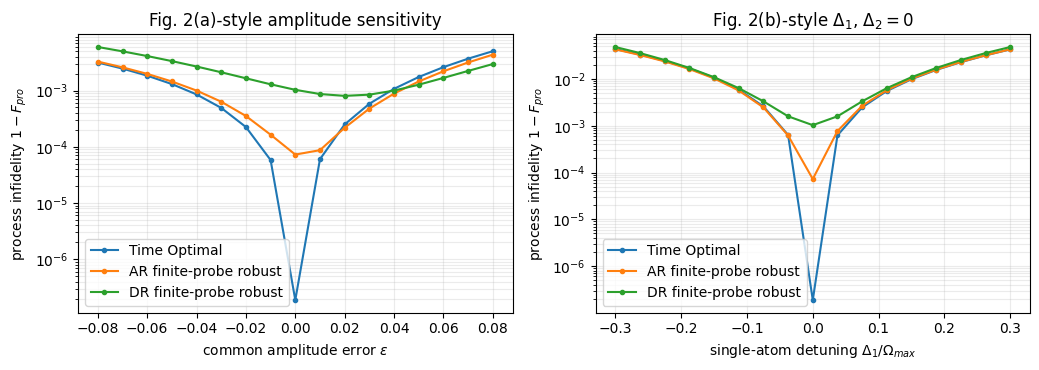

In [32]:
finite_probe_total_time = 14.32
finite_probe_num_tslots = 32
finite_probe_stretched_phases, _ = seed_phase_profile(num_tslots=finite_probe_num_tslots)
finite_probe_base_phases, finite_probe_base_fidelity = nominal_grape_phase_seed(
    total_time=finite_probe_total_time,
    num_tslots=finite_probe_num_tslots,
    initial_phases=finite_probe_stretched_phases,
    max_iter=80,
)

ar_finite_coefficients, ar_finite_optimization = optimize_bounded_compact_phase_family(
    lambda coeffs: finite_probe_robust_objective(
        coeffs,
        base_phases=finite_probe_base_phases,
        total_time=finite_probe_total_time,
        noise_kind="amplitude",
        probe_value=0.05,
        use_doppler_reversal=False,
    ),
    num_modes=3,
    max_iter=45,
    coefficient_bound=0.5,
)

dr_finite_coefficients, dr_finite_optimization = optimize_bounded_compact_phase_family(
    lambda coeffs: finite_probe_robust_objective(
        coeffs,
        base_phases=finite_probe_base_phases,
        total_time=finite_probe_total_time,
        noise_kind="detuning",
        probe_value=0.20,
        use_doppler_reversal=True,
    ),
    num_modes=3,
    max_iter=45,
    coefficient_bound=0.5,
)

ar_finite_phases = compact_phase_family(finite_probe_base_phases, finite_probe_total_time, ar_finite_coefficients)
dr_finite_phases = compact_phase_family(finite_probe_base_phases, finite_probe_total_time, dr_finite_coefficients)

finite_probe_tables = [
    finite_probe_fidelity_table(
        "Time Optimal, amplitude probes",
        finite_probe_base_phases,
        total_time=finite_probe_total_time,
        noise_kind="amplitude",
        probe_value=0.05,
    ),
    finite_probe_fidelity_table(
        "AR finite-probe robust, amplitude probes",
        ar_finite_phases,
        total_time=finite_probe_total_time,
        noise_kind="amplitude",
        probe_value=0.05,
    ),
    finite_probe_fidelity_table(
        "Time Optimal, DR detuning probes",
        finite_probe_base_phases,
        total_time=finite_probe_total_time,
        noise_kind="detuning",
        probe_value=0.20,
        use_doppler_reversal=True,
    ),
    finite_probe_fidelity_table(
        "DR finite-probe robust, DR detuning probes",
        dr_finite_phases,
        total_time=finite_probe_total_time,
        noise_kind="detuning",
        probe_value=0.20,
        use_doppler_reversal=True,
    ),
]

print(f"Finite-probe Time Optimal fidelity: {finite_probe_base_fidelity:.12f}")
print("Bounded finite-probe robust optimization")
for row in finite_probe_tables:
    print(
        f"{row['label']}: "
        f"F(-probe)={row['fidelity_minus_probe']:.12f}, "
        f"F(-half)={row['fidelity_minus_half_probe']:.12f}, "
        f"F0={row['fidelity_nominal']:.12f}, "
        f"F(+half)={row['fidelity_plus_half_probe']:.12f}, "
        f"F(+probe)={row['fidelity_plus_probe']:.12f}, "
        f"minF={row['minimum_probe_fidelity']:.12f}"
    )
print(
    f"AR finite-probe optimizer: success={bool(ar_finite_optimization.success)}; "
    f"nit={int(ar_finite_optimization.nit)}; nfev={int(ar_finite_optimization.nfev)}; "
    f"objective={float(ar_finite_optimization.fun):.6e}"
)
print(
    f"DR finite-probe optimizer: success={bool(dr_finite_optimization.success)}; "
    f"nit={int(dr_finite_optimization.nit)}; nfev={int(dr_finite_optimization.nfev)}; "
    f"objective={float(dr_finite_optimization.fun):.6e}"
)

finite_probe_candidates = {
    "Time Optimal": {"phases": finite_probe_base_phases, "total_time": finite_probe_total_time, "use_doppler_reversal": False},
    "AR finite-probe robust": {"phases": ar_finite_phases, "total_time": finite_probe_total_time, "use_doppler_reversal": False},
    "DR finite-probe robust": {"phases": dr_finite_phases, "total_time": finite_probe_total_time, "use_doppler_reversal": True},
}
plot_ot_ar_dr_error_comparison(finite_probe_candidates)

## Interpretation of bounded finite-probe robust pass

This section is the first actual robust optimization result in the notebook: the objective includes the two explicit noise families instead of only measuring them afterward. In the current compact Fourier search, AR balances the two `epsilon = ±0.05` endpoints and raises the minimum endpoint fidelity from `0.998262227353` for the Time Optimal to `0.998552745966`. DR now uses the Fig. 2(b)-style probe, `Delta_1` varied with `Delta_2=0`, and midpoint sign reversal for the DR candidate. It improves the `Delta_1/Omega = ±0.20` endpoints only modestly, from `0.979043468996` to `0.980303143863`; at the half probe `|Delta_1|/Omega = 0.10`, the DR candidate stays near `0.99481`.

The result should be treated as an executable reproduction checkpoint, not yet the final PRX Quantum full robust-GRAPE pulse. The next step is not more finite-probe tuning in this full-pulse compact family, but the paper's half-pulse DR construction with a first-order sensitivity-state GRAPE objective.


## Paper first-order sensitivity-state target

Purpose: define the three target branch states used by the PRX Quantum first-order robustness objective.

Inputs: local computational phases for the single-excitation branches.

Outputs: target states for `|10>`, `|01>`, and `|11>` branches.

Assumptions: the robust objective optimizes a CZ up to local phases, with the two-excitation branch carrying the extra minus sign.

In [33]:
def first_order_target_branch_states(theta10: float, theta01: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return (
        np.array([np.exp(1j * float(theta10)), 0.0], dtype=np.complex128),
        np.array([np.exp(1j * float(theta01)), 0.0], dtype=np.complex128),
        np.array([-np.exp(1j * (float(theta10) + float(theta01))), 0.0, 0.0], dtype=np.complex128),
    )

## Paper first-order detuning signs

Purpose: create the sign traces for the DR first-order detuning derivative.

Inputs: number of slots, the detuned atom, and whether midpoint Doppler sign reversal is active.

Outputs: two slot-wise traces multiplying the infinitesimal `Delta_1` and `Delta_2` parameters.

Assumptions: Fig. 2(b) uses `Delta_1` with `Delta_2=0`; DR uses an ideal instantaneous sign reversal of `Delta_1` at the midpoint.


In [34]:

def first_order_detuning_sign_trace(num_tslots: int, *, use_doppler_reversal: bool) -> np.ndarray:
    signs = np.ones(int(num_tslots), dtype=np.float64)
    if use_doppler_reversal:
        signs[int(num_tslots) // 2 :] = -1.0
    return signs


def first_order_detuning_sign_traces(
    num_tslots: int,
    *,
    detuned_atom: int = 1,
    use_doppler_reversal: bool,
) -> tuple[np.ndarray, np.ndarray]:
    signs = first_order_detuning_sign_trace(num_tslots, use_doppler_reversal=use_doppler_reversal)
    zeros = np.zeros(int(num_tslots), dtype=np.float64)
    if int(detuned_atom) == 1:
        return signs, zeros
    if int(detuned_atom) == 2:
        return zeros, signs
    raise ValueError("detuned_atom must be 1 or 2")


## Paper-style first-order robust objective

Purpose: minimize the paper's first-order sensitivity-state objective in a compact phase family.

Inputs: compact Fourier coefficients, local phases, a noise kind, and objective weights.

Outputs: a real residual vector for `scipy.optimize.least_squares`.

Assumptions: AR penalizes the full first-order sensitivity state. DR follows PRX Quantum Eq. (9): only the component orthogonal to the computational return state is penalized, because the computational-direction first-order phase is cancelled by the sign-reversed second half.


In [35]:

def first_order_robust_residual(
    variables: np.ndarray,
    *,
    base_phases: np.ndarray,
    total_time: float,
    noise_kind: str,
    num_coefficients: int,
    zero_order_weight: float,
    sensitivity_weight: float,
    regularization_weight: float = 1e-3,
    use_doppler_reversal: bool = False,
) -> np.ndarray:
    variables = np.asarray(variables, dtype=np.float64)
    coefficients = variables[: int(num_coefficients)]
    theta10, theta01 = variables[-2:]
    phases = compact_phase_family(base_phases, total_time, coefficients)
    detuning_1_signs = None
    detuning_2_signs = None
    if noise_kind == "detuning":
        detuning_1_signs, detuning_2_signs = first_order_detuning_sign_traces(
            phases.size,
            detuned_atom=1,
            use_doppler_reversal=use_doppler_reversal,
        )
    states, sensitivities = propagate_first_order_sensitivity(
        phases,
        total_time=total_time,
        noise_kind=noise_kind,
        detuning_1_sign_trace=detuning_1_signs,
        detuning_2_sign_trace=detuning_2_signs,
    )
    targets = first_order_target_branch_states(theta10, theta01)

    residual: list[float] = []
    for state, target in zip(states, targets, strict=True):
        delta = np.sqrt(float(zero_order_weight)) * (state - target)
        residual.extend(float(value) for value in delta.real)
        residual.extend(float(value) for value in delta.imag)
    for sensitivity in sensitivities:
        if noise_kind == "detuning":
            projected = np.asarray(sensitivity, dtype=np.complex128).copy()
            projected[0] = 0.0
            delta = np.sqrt(float(sensitivity_weight)) * projected
        else:
            delta = np.sqrt(float(sensitivity_weight)) * sensitivity
        residual.extend(float(value) for value in delta.real)
        residual.extend(float(value) for value in delta.imag)
    residual.extend(float(value) for value in (np.sqrt(float(regularization_weight)) * coefficients))
    return np.asarray(residual, dtype=np.float64)


## Paper first-order compact optimizer

Purpose: solve the compact first-order AR/DR objective with bounded least squares.

Inputs: base phases, duration, noise kind, Fourier mode count, robustness weights, and coefficient bounds.

Outputs: optimized phases, optimized coefficients, and the raw SciPy least-squares result.

Assumptions: the compact basis keeps the notebook fast enough to execute while testing the actual first-order sensitivity-state objective. Full slot-wise GRAPE remains the next step after this checkpoint.

In [36]:
def optimize_first_order_compact_phase_family(
    *,
    base_phases: np.ndarray,
    total_time: float,
    noise_kind: str,
    num_modes: int,
    zero_order_weight: float,
    sensitivity_weight: float,
    coefficient_bound: float = 0.8,
    max_nfev: int = 1600,
    use_doppler_reversal: bool = False,
) -> tuple[np.ndarray, np.ndarray, object]:
    num_coefficients = 2 * int(num_modes)
    nominal = evaluate_trace_pulse(base_phases, total_time=total_time)
    variables0 = np.concatenate(
        [
            np.zeros(num_coefficients, dtype=np.float64),
            np.array([float(nominal["theta10"]), float(nominal["theta01"])], dtype=np.float64),
        ]
    )
    lower = np.concatenate(
        [
            np.full(num_coefficients, -float(coefficient_bound), dtype=np.float64),
            np.zeros(2, dtype=np.float64),
        ]
    )
    upper = np.concatenate(
        [
            np.full(num_coefficients, float(coefficient_bound), dtype=np.float64),
            np.full(2, 2.0 * np.pi, dtype=np.float64),
        ]
    )
    result = least_squares(
        lambda variables: first_order_robust_residual(
            variables,
            base_phases=base_phases,
            total_time=total_time,
            noise_kind=noise_kind,
            num_coefficients=num_coefficients,
            zero_order_weight=zero_order_weight,
            sensitivity_weight=sensitivity_weight,
            use_doppler_reversal=use_doppler_reversal,
        ),
        variables0,
        bounds=(lower, upper),
        max_nfev=int(max_nfev),
        xtol=1e-7,
        ftol=1e-7,
        gtol=1e-7,
    )
    coefficients = np.asarray(result.x[:num_coefficients], dtype=np.float64)
    phases = compact_phase_family(base_phases, total_time, coefficients)
    return phases, coefficients, result

## Paper first-order robustness summary

Purpose: collect finite-probe diagnostics and first-order sensitivity norms for the paper-style robust candidates.

Inputs: label, phases, duration, noise kind, and probe settings.

Outputs: dictionary with nominal fidelity, finite-probe endpoint fidelities, and first-order sensitivity norm.

Assumptions: finite probes are diagnostic only; the optimized objective is the first-order sensitivity-state residual.

In [37]:

def first_order_robust_summary(
    label: str,
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    probe_value: float,
    use_doppler_reversal: bool = False,
) -> dict[str, float | str]:
    phases = np.asarray(phases, dtype=np.float64)
    nominal = evaluate_trace_pulse(phases, total_time=total_time)
    if noise_kind == "amplitude":
        minus = evaluate_trace_pulse(
            phases,
            total_time=total_time,
            epsilon_1_trace=np.full(phases.size, -probe_value, dtype=np.float64),
            epsilon_2_trace=np.full(phases.size, -probe_value, dtype=np.float64),
        )
        plus = evaluate_trace_pulse(
            phases,
            total_time=total_time,
            epsilon_1_trace=np.full(phases.size, probe_value, dtype=np.float64),
            epsilon_2_trace=np.full(phases.size, probe_value, dtype=np.float64),
        )
        detuning_1_signs = None
        detuning_2_signs = None
    elif noise_kind == "detuning":
        minus_det1, minus_det2 = single_atom_detuning_traces(
            phases.size,
            -probe_value,
            detuned_atom=1,
            use_doppler_reversal=use_doppler_reversal,
        )
        plus_det1, plus_det2 = single_atom_detuning_traces(
            phases.size,
            probe_value,
            detuned_atom=1,
            use_doppler_reversal=use_doppler_reversal,
        )
        minus = evaluate_trace_pulse(phases, total_time=total_time, detuning_1_trace=minus_det1, detuning_2_trace=minus_det2)
        plus = evaluate_trace_pulse(phases, total_time=total_time, detuning_1_trace=plus_det1, detuning_2_trace=plus_det2)
        detuning_1_signs, detuning_2_signs = first_order_detuning_sign_traces(
            phases.size,
            detuned_atom=1,
            use_doppler_reversal=use_doppler_reversal,
        )
    else:
        raise ValueError("noise_kind must be 'amplitude' or 'detuning'")

    _states, sensitivities = propagate_first_order_sensitivity(
        phases,
        total_time=total_time,
        noise_kind=noise_kind,
        detuning_1_sign_trace=detuning_1_signs,
        detuning_2_sign_trace=detuning_2_signs,
    )
    sensitivity_norm = 0.0
    for branch in sensitivities:
        if noise_kind == "detuning":
            projected = np.asarray(branch, dtype=np.complex128).copy()
            projected[0] = 0.0
            sensitivity_norm += float(np.vdot(projected, projected).real)
        else:
            sensitivity_norm += float(np.vdot(branch, branch).real)
    return {
        "label": label,
        "nominal_fidelity": float(nominal["process_fidelity"]),
        "minus_probe_fidelity": float(minus["process_fidelity"]),
        "plus_probe_fidelity": float(plus["process_fidelity"]),
        "minimum_probe_fidelity": float(min(float(minus["process_fidelity"]), float(plus["process_fidelity"]))),
        "sensitivity_norm": float(sensitivity_norm),
    }


## Execute paper first-order AR/DR optimization

This cell implements the next step after the finite-probe pass: the optimization objective contains the first-order sensitivity states `psi_q^(1)` from the PRX Quantum AR/DR construction.

The compact Fourier basis is still intentionally small enough for notebook execution, but the optimized residual is now the paper-style first-order residual rather than a finite-noise grid.

First-order Time Optimal fidelity: 0.999999981757
Paper-style first-order sensitivity-state robust optimization
Time Optimal, amplitude sensitivity: F0=0.999999981780, F(-probe)=0.997167125131, F(+probe)=0.995662275603, minF=0.995662275603, S1=9.636384e+01
AR first-order robust: F0=0.999991477077, F(-probe)=0.996558440020, F(+probe)=0.997303244986, minF=0.996558440020, S1=5.740975e+00
Time Optimal, DR sensitivity: F0=0.999999981780, F(-probe)=0.976711957540, F(+probe)=0.976712590892, minF=0.976711957540, S1=1.917865e+00
DR first-order robust: F0=0.986372734744, F(-probe)=0.906992297543, F(+probe)=0.936275991557, minF=0.906992297543, S1=7.005785e+00
AR first-order optimizer: success=True; nfev=86; cost=5.779418e+00
DR first-order optimizer: success=True; nfev=38; cost=9.520231e+01


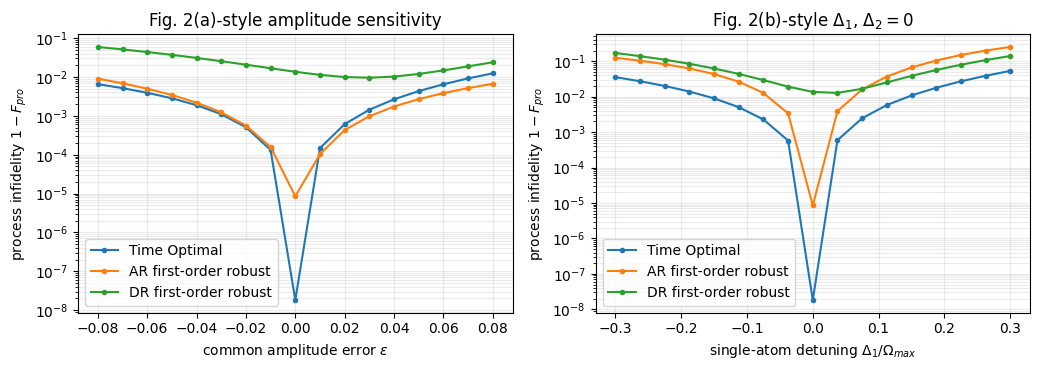

In [38]:
first_order_total_time = 14.32
first_order_num_tslots = 40
first_order_seed_phases, _ = seed_phase_profile(num_tslots=first_order_num_tslots)
first_order_base_phases, first_order_base_fidelity = nominal_grape_phase_seed(
    total_time=first_order_total_time,
    num_tslots=first_order_num_tslots,
    initial_phases=first_order_seed_phases,
    max_iter=80,
)

ar_first_order_phases, ar_first_order_coefficients, ar_first_order_optimization = optimize_first_order_compact_phase_family(
    base_phases=first_order_base_phases,
    total_time=first_order_total_time,
    noise_kind="amplitude",
    num_modes=5,
    zero_order_weight=1000.0,
    sensitivity_weight=1.0,
    coefficient_bound=0.8,
    max_nfev=1600,
)

dr_first_order_phases, dr_first_order_coefficients, dr_first_order_optimization = optimize_first_order_compact_phase_family(
    base_phases=first_order_base_phases,
    total_time=first_order_total_time,
    noise_kind="detuning",
    num_modes=5,
    zero_order_weight=1000.0,
    sensitivity_weight=5.0,
    coefficient_bound=0.8,
    max_nfev=1600,
    use_doppler_reversal=True,
)

first_order_tables = [
    first_order_robust_summary(
        "Time Optimal, amplitude sensitivity",
        first_order_base_phases,
        total_time=first_order_total_time,
        noise_kind="amplitude",
        probe_value=0.05,
    ),
    first_order_robust_summary(
        "AR first-order robust",
        ar_first_order_phases,
        total_time=first_order_total_time,
        noise_kind="amplitude",
        probe_value=0.05,
    ),
    first_order_robust_summary(
        "Time Optimal, DR sensitivity",
        first_order_base_phases,
        total_time=first_order_total_time,
        noise_kind="detuning",
        probe_value=0.20,
        use_doppler_reversal=True,
    ),
    first_order_robust_summary(
        "DR first-order robust",
        dr_first_order_phases,
        total_time=first_order_total_time,
        noise_kind="detuning",
        probe_value=0.20,
        use_doppler_reversal=True,
    ),
]

print(f"First-order Time Optimal fidelity: {first_order_base_fidelity:.12f}")
print("Paper-style first-order sensitivity-state robust optimization")
for row in first_order_tables:
    print(
        f"{row['label']}: "
        f"F0={row['nominal_fidelity']:.12f}, "
        f"F(-probe)={row['minus_probe_fidelity']:.12f}, "
        f"F(+probe)={row['plus_probe_fidelity']:.12f}, "
        f"minF={row['minimum_probe_fidelity']:.12f}, "
        f"S1={row['sensitivity_norm']:.6e}"
    )
print(
    f"AR first-order optimizer: success={bool(ar_first_order_optimization.success)}; "
    f"nfev={int(ar_first_order_optimization.nfev)}; cost={float(2.0 * ar_first_order_optimization.cost):.6e}"
)
print(
    f"DR first-order optimizer: success={bool(dr_first_order_optimization.success)}; "
    f"nfev={int(dr_first_order_optimization.nfev)}; cost={float(2.0 * dr_first_order_optimization.cost):.6e}"
)

first_order_candidates = {
    "Time Optimal": {"phases": first_order_base_phases, "total_time": first_order_total_time, "use_doppler_reversal": False},
    "AR first-order robust": {"phases": ar_first_order_phases, "total_time": first_order_total_time, "use_doppler_reversal": False},
    "DR first-order robust": {"phases": dr_first_order_phases, "total_time": first_order_total_time, "use_doppler_reversal": True},
}
plot_ot_ar_dr_error_comparison(first_order_candidates)

## Interpretation of paper first-order robust pass

This section now uses the Fig. 2(b) detuning convention: `Delta_1` is varied and `Delta_2=0`. It also uses the PRX Quantum Eq. (9) projection for DR, where only the component of `psi_q^(1)` orthogonal to the computational return state is penalized. AR behaves as expected in this compact basis: the amplitude-sensitivity norm drops from `9.636384e+01` to `5.740975e+00` while keeping `F0 = 0.999991477077`; the finite diagnostic endpoints at `epsilon = ±0.05` move from a worst value of `0.995662275603` to `0.996558440020`.

The corrected DR diagnostic does not reproduce Fig. 2(b): Time Optimal has worst endpoint fidelity `0.976711957540` at `Delta_1/Omega = ±0.20`, while the current compact DR search drops to `0.906992297543` with `F0 = 0.986372734744`. This is a useful failure mode. The earlier discrepancy came from two modeling mistakes, common detuning instead of single-atom `Delta_1`, and an over-constrained DR first-order residual. After fixing those, the remaining mismatch is the pulse construction: the paper optimizes a CRz(pi/2) half-pulse and applies the same half-pulse twice with Doppler sign reversal, whereas this notebook still searches a compact full-pulse correction family. The next implementation step is therefore a half-pulse GRAPE construction before claiming publication-level DR/ADR/CADR reproduction.
